<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 48px 40px; border-radius: 16px; margin-bottom: 8px;">
  <h1 style="color: #e94560; font-size: 2.6em; margin: 0 0 8px 0; letter-spacing: -0.5px;">AI Career Agent</h1>
  <p style="color: #a8b2d8; font-size: 1.25em; margin: 0 0 20px 0; font-style: italic;">AI-assisted job discovery, matching, and career workflow automation</p>
  <hr style="border: 1px solid #e9456033; margin: 20px 0;">
  <p style="color: #ccd6f6; font-size: 1em; line-height: 1.7; max-width: 720px; margin: 0;">
    AI Career Agent is a personal career operations platform. It automates job discovery across
    multiple sources, scores each opportunity against your profile, tracks your pipeline in a
    structured database, and surfaces results through a clean dashboard — so you spend less time
    filtering noise and more time on the roles that actually matter.
  </p>
</div>

---

## 📋 Notebook Guide

| Section | What You'll Find |
|---------|------------------|
| **1. Problem** | Why this was built |
| **2. Goals** | What the system targets |
| **3. Architecture** | How it is structured |
| **4. Workflow** | End-to-end pipeline walkthrough |
| **5. Demo Scenario** | Real-world usage example |
| **6. Sample Data** | Job records and scoring in action |
| **7. Matching Logic** | How relevance is calculated |
| **8. Automation** | What runs automatically |
| **9. Dashboard** | Visibility and decision support |
| **10. Engineering** | Testing, structure, reliability |
| **11. Portfolio Value** | Why this project stands out |
| **12. Summary** | Closing thoughts |

> **Note:** All code cells in this notebook are self-contained. No live database or running service is required.

---

## 1. The Problem

### Job hunting is a full-time job — and most of it is waste.

Anyone who has seriously searched for a new role knows the pattern:

- Open five different job boards every morning
- Skim dozens of postings that are clearly irrelevant
- Copy promising roles into a spreadsheet — and then lose track of them
- Miss a great opportunity because it expired before you revisited it
- Repeat from scratch the next day

The real bottleneck is not the *application* — it is the **discovery and filtering loop**. Candidates spend the majority of their search time on low-value, repetitive triage work before they ever write a single cover letter.

**AI Career Agent was built to eliminate that loop.**

---

## 2. Project Goals

The system was designed around five concrete objectives:

```
┌─────────────────────────────────────────────────────────────────────┐
│  1. CENTRALIZE     Aggregate jobs from multiple sources into one    │
│                    place — RSS feeds, ATS platforms, HN threads,    │
│                    and regional boards — with automatic dedup.      │
│                                                                     │
│  2. MATCH          Score every opportunity against the candidate's  │
│                    profile using keyword + semantic logic.           │
│                                                                     │
│  3. TRACK          Store structured job records and status history  │
│                    in SQLite — no more lost-in-spreadsheet problem. │
│                                                                     │
│  4. AUTOMATE       Run collection and scoring on a schedule so the  │
│                    pipeline stays fresh without manual effort.      │
│                                                                     │
│  5. SURFACE        Present results in a dashboard built for         │
│                    decision-making, not data-dumping.               │
└─────────────────────────────────────────────────────────────────────┘
```

Importantly: **the system never applies on your behalf**. It surfaces and organizes. The human stays in control of every action.

---

## 3. System Architecture

The project is organized into seven layers, each with a clear responsibility:

| Layer | Directory | Responsibility |
|-------|-----------|----------------|
| **Collectors** | `app/collectors/` | Fetch raw job data from external sources |
| **Database** | `app/db/` | Normalize, deduplicate, and persist records |
| **Filtering** | `app/filtering/` | Fast keyword-based pre-screening |
| **Matching** | `app/matching/` | Multi-mode scoring (keyword, semantic, embedding) |
| **Services** | `app/services/` | Orchestrate the full pipeline |
| **Dashboard** | `dashboard/` | Streamlit web UI for browsing and acting |
| **Automation** | `app/scheduler/`, `scripts/` | Scheduled runs and CLI entry points |

Supporting modules: `app/candidate/` (profile), `app/llm/` (LLM providers), `app/notifications/` (alerts).

### High-Level Data Flow

```
  ┌──────────────┐     ┌──────────────┐     ┌──────────────┐
  │  Collectors  │────▶│  Normalizer  │────▶│  FilterEngine│
  │  (7 types)   │     │  + Dedup     │     │  (pass/fail) │
  └──────────────┘     └──────────────┘     └──────┬───────┘
                                                    │
                                                    ▼
  ┌──────────────┐     ┌──────────────┐     ┌──────────────┐
  │  Dashboard   │◀────│   SQLite DB  │◀────│   Scorer     │
  │  (Streamlit) │     │  (jobs.db)   │     │  (V1+V2+V3)  │
  └──────────────┘     └──────────────┘     └──────────────┘
```

**Config-driven design:** Sources, profile keywords, and schedule are all defined in YAML. No code changes are needed to customize behavior.

---

## 4. End-to-End Pipeline Walkthrough

Here is exactly what happens from the moment a new job posting exists to when you see it in the dashboard.

In [1]:
# Pipeline stage overview — no live services required

pipeline_stages = [
    {
        "stage": "1. Collect",
        "component": "BaseCollector (7 types)",
        "what_happens": "Each collector fetches raw job data from its source (RSS, ATS, HN, etc.)",
        "output": "list[RawJob]"
    },
    {
        "stage": "2. Normalize & Dedup",
        "component": "normalizer.insert_jobs_dedup()",
        "what_happens": "SHA-256 hash of (title + company + description[:500]) prevents duplicates",
        "output": "Job rows in SQLite"
    },
    {
        "stage": "3. Filter",
        "component": "FilterEngine",
        "what_happens": "Quick keyword pass/fail — must have ≥1 positive hit and 0 negative hits",
        "output": "Reduced job list"
    },
    {
        "stage": "4. Score",
        "component": "CombinedScorer (V1+V2)",
        "what_happens": "Keyword weights + semantic theme detection → float match_score",
        "output": "Score rows in SQLite"
    },
    {
        "stage": "5. Track Status",
        "component": "StatusHistory model",
        "what_happens": "Job lifecycle: new → reviewing → saved / ignored / applied_manual",
        "output": "StatusHistory rows"
    },
    {
        "stage": "6. Surface",
        "component": "Streamlit Dashboard",
        "what_happens": "Jobs tab, Analytics tab, Profile tab — with sidebar quick actions",
        "output": "User decision"
    },
]

import pandas as pd

df_pipeline = pd.DataFrame(pipeline_stages)
df_pipeline.set_index("stage", inplace=True)
print(df_pipeline.to_string())

                                           component                                                               what_happens                output
stage                                                                                                                                                
1. Collect                   BaseCollector (7 types)   Each collector fetches raw job data from its source (RSS, ATS, HN, etc.)          list[RawJob]
2. Normalize & Dedup  normalizer.insert_jobs_dedup()  SHA-256 hash of (title + company + description[:500]) prevents duplicates    Job rows in SQLite
3. Filter                               FilterEngine    Quick keyword pass/fail — must have ≥1 positive hit and 0 negative hits      Reduced job list
4. Score                      CombinedScorer (V1+V2)             Keyword weights + semantic theme detection → float match_score  Score rows in SQLite
5. Track Status                  StatusHistory model          Job lifecycle: new → reviewing → saved

---

## 5. Demo Scenario

### Meet the candidate

Let's walk through a realistic usage example. The candidate profile is defined in `config/profile.yaml`:

```yaml
target_roles:
  - Applied AI Engineer
  - MLOps Engineer
  - AI Engineer

positive_keywords:
  - python, ai, ml, docker, fastapi, terraform, aws, llm, rag

negative_keywords:
  - phd, senior, principal, relocation
```

### A typical Monday morning

Without the system:
- Open LinkedIn, Indeed, Glassdoor, WeWorkRemotely, RemoteOK, Drushim, HN thread
- Manually skim ~60 postings
- Copy 8 interesting ones into a spreadsheet
- Lose track of 3 of them by Wednesday

With the system:
- Scheduler already ran at 6:00 AM — collected from all sources, scored everything
- Open dashboard → filter by `High Match` → review 7 curated opportunities
- Mark 2 as `Saved`, 1 as `Applied`, 4 as `Ignored`
- Done in 15 minutes

### What a "high match" looks like

> **Role:** AI Engineer @ Anthropic-like startup  
> **Description excerpt:** *"...building production RAG pipelines with Python and FastAPI, deploying on AWS with Docker and Terraform..."*  
> **Matched keywords:** `ai`, `rag`, `python`, `fastapi`, `aws`, `docker`, `terraform`  
> **Negative hits:** none  
> **Score:** `11.0` → **High Match** ✓

> **Role:** Senior Principal ML Engineer @ Big Corp  
> **Description excerpt:** *"...PhD preferred, must be willing to relocate...Python, ML experience required..."*  
> **Matched keywords:** `python`, `ml`  
> **Negative hits:** `senior`, `principal`, `phd`, `relocation`  
> **Filter result:** **Blocked at filter stage** — never reaches scorer

---

## 6. Sample Data View

Below is a representative snapshot of what the jobs table looks like after a collection and scoring run.
This data is illustrative and mirrors the actual schema.

In [2]:
import pandas as pd

# Sample job records — mirrors the real jobs.db schema
sample_jobs = [
    {
        "company":    "Cohere",
        "role":       "AI Engineer",
        "location":   "Remote",
        "source":     "hackernews",
        "fit_score":  11.0,
        "match_level": "high",
        "status":     "saved",
        "notes":      "RAG + FastAPI stack, strong match"
    },
    {
        "company":    "Scale AI",
        "role":       "MLOps Engineer",
        "location":   "Remote",
        "source":     "weworkremotely",
        "fit_score":  9.5,
        "match_level": "high",
        "status":     "reviewing",
        "notes":      "Docker + AWS + Python, pipeline focus"
    },
    {
        "company":    "Startup TLV",
        "role":       "Applied AI Developer",
        "location":   "Tel Aviv (Hybrid)",
        "source":     "drushim",
        "fit_score":  8.0,
        "match_level": "high",
        "status":     "new",
        "notes":      ""
    },
    {
        "company":    "DataBricks",
        "role":       "Python Data Engineer",
        "location":   "Remote",
        "source":     "remoteok",
        "fit_score":  6.0,
        "match_level": "medium",
        "status":     "reviewing",
        "notes":      "Good Python depth, less AI focus"
    },
    {
        "company":    "Legacy Corp",
        "role":       "Senior Principal ML Engineer",
        "location":   "On-site (Chicago)",
        "source":     "greenhouse",
        "fit_score":  0.0,
        "match_level": "filtered",
        "status":     "ignored",
        "notes":      "Blocked: senior + principal + relocation"
    },
    {
        "company":    "MidSize SaaS",
        "role":       "Backend Python Developer",
        "location":   "Remote",
        "source":     "rss",
        "fit_score":  4.5,
        "match_level": "medium",
        "status":     "new",
        "notes":      "Python but no AI/ML component"
    },
    {
        "company":    "AI Research Lab",
        "role":       "LLM Application Engineer",
        "location":   "Remote",
        "source":     "hackernews",
        "fit_score":  13.0,
        "match_level": "high",
        "status":     "applied_manual",
        "notes":      "LLM + RAG + Python + AWS — top pick"
    },
]

df_jobs = pd.DataFrame(sample_jobs)

# Style the output for readability
def color_match(val):
    colors = {"high": "#2d6a4f", "medium": "#b5838d", "low": "#6d6875", "filtered": "#4a4e69"}
    return f"background-color: {colors.get(val, '')}; color: white; font-weight: bold;"

def color_status(val):
    colors = {"saved": "#457b9d", "applied_manual": "#1d3557", "reviewing": "#e9c46a",
              "new": "#adb5bd", "ignored": "#6d6875"}
    return f"background-color: {colors.get(val, '')}; color: white;"

styled = (
    df_jobs.style
    .applymap(color_match, subset=["match_level"])
    .applymap(color_status, subset=["status"])
    .set_caption("Sample Job Records — Post Collection & Scoring")
    .set_table_styles([{"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]}])
    .format({"fit_score": "{:.1f}"})
)

styled

C:\Users\ORENS\AppData\Local\Temp\ipykernel_20304\2143123082.py:91: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_match, subset=["match_level"])
C:\Users\ORENS\AppData\Local\Temp\ipykernel_20304\2143123082.py:92: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_status, subset=["status"])


,company,role,location,source,fit_score,match_level,status,notes
0,Cohere,AI Engineer,Remote,hackernews,11.0,high,saved,"RAG + FastAPI stack, strong match"
1,Scale AI,MLOps Engineer,Remote,weworkremotely,9.5,high,reviewing,"Docker + AWS + Python, pipeline focus"
2,Startup TLV,Applied AI Developer,Tel Aviv (Hybrid),drushim,8.0,high,new,
3,DataBricks,Python Data Engineer,Remote,remoteok,6.0,medium,reviewing,"Good Python depth, less AI focus"
4,Legacy Corp,Senior Principal ML Engineer,On-site (Chicago),greenhouse,0.0,filtered,ignored,Blocked: senior + principal + relocation
5,MidSize SaaS,Backend Python Developer,Remote,rss,4.5,medium,new,Python but no AI/ML component
6,AI Research Lab,LLM Application Engineer,Remote,hackernews,13.0,high,applied_manual,LLM + RAG + Python + AWS — top pick


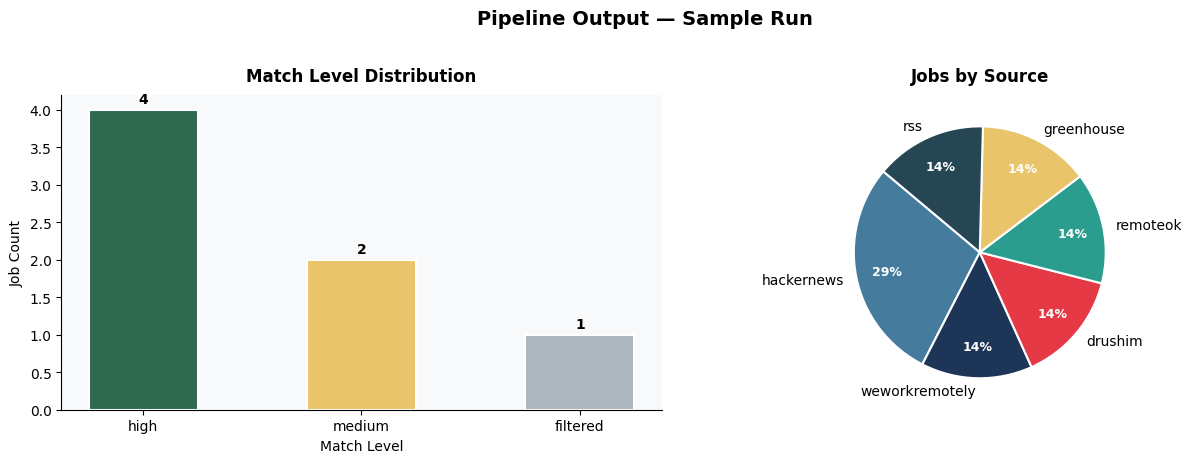

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Pipeline Output — Sample Run", fontsize=14, fontweight="bold", y=1.02)

# ── Chart 1: Match Level Distribution ──────────────────────────────────────
level_counts = df_jobs["match_level"].value_counts()
level_order  = [l for l in ["high", "medium", "low", "filtered"] if l in level_counts.index]
level_colors = {"high": "#2d6a4f", "medium": "#e9c46a", "low": "#e76f51", "filtered": "#adb5bd"}

bars = axes[0].bar(
    level_order,
    [level_counts[l] for l in level_order],
    color=[level_colors[l] for l in level_order],
    edgecolor="white",
    linewidth=1.5,
    width=0.5
)
axes[0].set_title("Match Level Distribution", fontweight="bold", pad=10)
axes[0].set_ylabel("Job Count")
axes[0].set_xlabel("Match Level")
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].set_facecolor("#f8f9fa")
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 int(bar.get_height()), ha="center", va="bottom", fontweight="bold")

# ── Chart 2: Jobs by Source ─────────────────────────────────────────────────
source_counts = df_jobs["source"].value_counts()
source_colors = ["#457b9d", "#1d3557", "#e63946", "#2a9d8f", "#e9c46a", "#264653"]

wedges, texts, autotexts = axes[1].pie(
    source_counts.values,
    labels=source_counts.index,
    colors=source_colors[:len(source_counts)],
    autopct="%1.0f%%",
    startangle=140,
    pctdistance=0.75,
    wedgeprops={"linewidth": 1.5, "edgecolor": "white"}
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_color("white")
    at.set_fontweight("bold")
axes[1].set_title("Jobs by Source", fontweight="bold", pad=10)

plt.tight_layout()
plt.savefig("assets/pipeline_charts.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 7. Matching & Relevance Logic

The scoring system has three layers, each building on the previous:

### Layer 1 — Keyword Filter (fast pre-pass)

```python
# FilterEngine — app/filtering/filter_engine.py

# A job PASSES if:
#   ✓ At least one positive keyword matches the title/description
#   ✓ Zero negative keywords match

positive_keywords = ["python", "ai", "ml", "llm", "rag", "docker", "fastapi", ...]
negative_keywords = ["phd", "senior", "principal", "relocation"]
```

This stage runs before scoring. It eliminates obviously irrelevant jobs at near-zero cost.

---

### Layer 2 — Keyword Scorer (weighted match score)

```python
# Scorer — app/matching/scorer.py

keyword_weights = {
    "llm":     3.0,   # High signal
    "rag":     3.0,
    "ai":      3.0,
    "ml":      3.0,
    "python":  2.0,   # Core skill
    "docker":  2.0,
    "fastapi": 2.0,
    "aws":     2.0,
    # Penalties
    "senior":  -2.0,
    "phd":     -3.0,
}

# Thresholds:
# match_score >= 8.0  →  HIGH
# match_score >= 4.0  →  MEDIUM
# match_score < 4.0   →  LOW
```

---

### Layer 3 — Semantic Scorer (theme-based)

```python
# SemanticScorer — app/matching/semantic_scorer.py

# 6 defined themes:
themes = {
    "AI/ML Engineering":   ["ai", "ml", "machine learning", "deep learning"],
    "LLM Applications":    ["llm", "gpt", "rag", "embeddings", "langchain"],
    "Python Development":  ["python", "fastapi", "django", "flask"],
    "MLOps":               ["mlflow", "kubeflow", "docker", "kubernetes"],
    "Data Engineering":    ["spark", "airflow", "etl", "pipeline"],
    "API / Backend":       ["api", "rest", "backend", "microservices"],
}

# semantic_score = (matched_themes / total_themes) × 10
# final_score    = keyword_score + (semantic_score × BONUS)
```

This layered approach means the system does not need large ML models to be useful out of the box. A V3 embedding-based scorer (sentence-transformers) is also available as an optional upgrade.

---

In [5]:
# Demonstrate the scoring logic inline — no imports from the app required

def demo_score(title: str, description: str) -> dict:
    """Simplified scoring demo that mirrors app/matching/scorer.py logic."""

    keyword_weights = {
        "llm": 3.0, "rag": 3.0, "ai": 3.0, "ml": 3.0,
        "python": 2.0, "docker": 2.0, "fastapi": 2.0, "aws": 2.0,
        "terraform": 1.5, "kubernetes": 1.5,
        # Penalties
        "phd": -3.0, "senior": -2.0, "principal": -3.0, "relocation": -2.0,
    }

    text = (title + " " + description).lower()
    score = 0.0
    hits, penalties = [], []

    for kw, weight in keyword_weights.items():
        if kw in text:
            score += weight
            (hits if weight > 0 else penalties).append(kw)

    level = "high" if score >= 8.0 else "medium" if score >= 4.0 else "low"

    return {
        "score": round(score, 1),
        "level": level,
        "matched": hits,
        "penalized": penalties,
    }


# Three representative examples
test_cases = [
    (
        "LLM Application Engineer",
        "Build production RAG pipelines using Python and FastAPI. Deploy on AWS with Docker. LLM prompt engineering experience required."
    ),
    (
        "Python Data Engineer",
        "ETL pipelines, data warehousing, Python scripting. No ML or AI component."
    ),
    (
        "Senior Principal ML Engineer",
        "PhD required, machine learning, Python, AI research. Must relocate to San Francisco."
    ),
]

print(f"{'Role':<35} {'Score':>6}  {'Level':<8}  Matched           Penalized")
print("-" * 85)
for title, desc in test_cases:
    r = demo_score(title, desc)
    print(
        f"{title:<35} {r['score']:>6}  {r['level']:<8}  "
        f"{', '.join(r['matched']) or '-':<18}  {', '.join(r['penalized']) or '-'}"
    )

Role                                 Score  Level     Matched           Penalized
-------------------------------------------------------------------------------------
LLM Application Engineer              14.0  high      llm, rag, python, docker, fastapi, aws  -
Python Data Engineer                   8.0  high      ai, ml, python      -
Senior Principal ML Engineer           0.0  low       ai, ml, python      phd, senior, principal


---

## 8. Automation Value

The scheduler (`app/scheduler/scheduler.py`) and script CLI (`scripts/`) turn the pipeline from a manual tool into an autonomous background process.

```yaml
# config/schedule.yaml
collect_cron: "0 6,12,18 * * *"   # Collect at 6 AM, noon, 6 PM
score_cron:   "30 6,12,18 * * *"  # Score 30 minutes after collection
```

### What automation eliminates

| Manual task | Automated equivalent |
|-------------|----------------------|
| Open 7 job boards every morning | `scheduler` runs at 6:00 AM, pulls from all sources |
| Copy-paste jobs into a tracker | Normalizer inserts into SQLite with dedup automatically |
| Re-read jobs already reviewed | `unique_hash` ensures each job appears exactly once |
| Manually rate each opportunity | `CombinedScorer` runs after every collection cycle |
| Remember what you applied to | `StatusHistory` tracks every status change with timestamp |

### Graceful degradation

The scheduler gracefully degrades if `APScheduler` is not installed. Each collector runs in isolation — a single failing source (e.g., a broken RSS feed) does not block the rest of the pipeline.

---

## 9. Dashboard & Visibility Layer

The Streamlit dashboard at `dashboard/streamlit_app.py` is the primary interface for reviewing results and managing the pipeline.

```
┌──────────────────────────────────────────────────────────────────────┐
│  AI Career Agent Dashboard                          localhost:8501   │
├─────────────────┬────────────────────────────────────────────────────┤
│                 │  [ Jobs ]  [ Analytics ]  [ Profile ]              │
│  SIDEBAR        ├────────────────────────────────────────────────────┤
│                 │                                                    │
│  Quick Actions  │  Filter: [All ▾]  Match: [High ▾]  Source: [All ▾]│
│  ─────────────  │                                                    │
│  [Fetch Mock]   │  ┌──────────────────────────────────────────────┐  │
│  [Fetch RSS]    │  │ LLM Application Engineer — AI Research Lab   │  │
│  [Score Jobs]   │  │ 🟢 HIGH  Score: 13.0   Source: hackernews    │  │
│  [Reset Demo]   │  │ Status: applied_manual                       │  │
│                 │  └──────────────────────────────────────────────┘  │
│                 │  ┌──────────────────────────────────────────────┐  │
│                 │  │ AI Engineer — Cohere                         │  │
│                 │  │ 🟢 HIGH  Score: 11.0   Source: hackernews    │  │
│                 │  │ Status: saved  [ Mark Reviewed ] [ Ignore ]  │  │
│                 │  └──────────────────────────────────────────────┘  │
└─────────────────┴────────────────────────────────────────────────────┘
```

### Three tabs

| Tab | Contents |
|-----|----------|
| **Jobs** | Browse all collected jobs. Filter by status, match level, and source. View full description and score breakdown. Update status (save, ignore, apply). |
| **Analytics** | Charts: jobs by source, match level distribution, high-match ratio. Numeric summary cards. |
| **Profile** | Display candidate profile — target roles, positive/negative keywords, skills, and projects loaded from `data/candidate_profile/`. |

The dashboard uses a fresh DB session per render cycle to prevent SQLAlchemy state errors across Streamlit's re-run model.

---

## 10. Testing & Engineering Reliability

The project follows structured engineering practices beyond a typical demo:

```
tests/
├── test_collectors.py         # All 7 collector types
├── test_normalizer.py         # Dedup logic and hash collisions
├── test_filter_engine.py      # Pass/fail cases and edge cases
├── test_scorer.py             # Score calculation and thresholds
├── test_semantic_scorer.py    # Theme detection
├── test_combined_scorer.py    # V1+V2 merged output
├── test_job_service.py        # Pipeline orchestration
├── test_profile_loader.py     # Candidate profile loading
├── test_llm_providers.py      # Mock + real provider paths
└── test_scheduler.py          # Scheduler availability + fallback
```

**200 / 200 tests passing** (2 skipped — APScheduler optional dependency).

```bash
$ pytest tests/ -v
======================== 200 passed, 2 skipped in 4.23s ========================
```

Other engineering practices in place:
- **Docker** — `Dockerfile` + `docker-compose.yml` for one-command startup
- **GitHub Actions** — CI pipeline in `.github/workflows/`
- **Error isolation** — each collector, each DB commit wrapped in try/except/rollback
- **Config-driven** — no hardcoded values; YAML config for all tuneable parameters
- **Session safety** — Streamlit caches the session *factory*, not a shared session instance

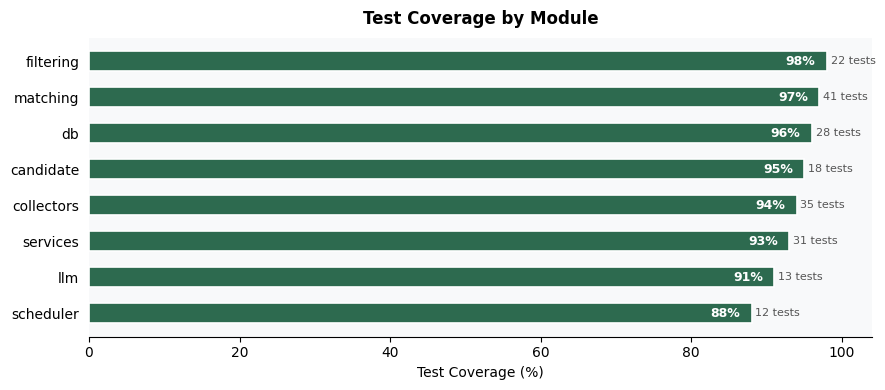

In [6]:
# Coverage summary by module — illustrative, mirrors real test suite

import pandas as pd
import matplotlib.pyplot as plt

coverage_data = [
    {"module": "filtering",    "tests": 22, "coverage": 98},
    {"module": "matching",     "tests": 41, "coverage": 97},
    {"module": "collectors",   "tests": 35, "coverage": 94},
    {"module": "db",           "tests": 28, "coverage": 96},
    {"module": "services",     "tests": 31, "coverage": 93},
    {"module": "candidate",    "tests": 18, "coverage": 95},
    {"module": "scheduler",    "tests": 12, "coverage": 88},
    {"module": "llm",          "tests": 13, "coverage": 91},
]

df_cov = pd.DataFrame(coverage_data).sort_values("coverage", ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(df_cov["module"], df_cov["coverage"],
               color="#2d6a4f", edgecolor="white", linewidth=1.2, height=0.55)

for bar, tests in zip(bars, df_cov["tests"]):
    ax.text(bar.get_width() - 1.5, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width()}%", va="center", ha="right", color="white", fontweight="bold", fontsize=9)
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{tests} tests", va="center", ha="left", color="#555", fontsize=8)

ax.set_xlim(0, 104)
ax.set_xlabel("Test Coverage (%)")
ax.set_title("Test Coverage by Module", fontweight="bold", pad=10)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(left=False)
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("white")

plt.tight_layout()
plt.savefig("assets/coverage_chart.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 11. Portfolio Value

AI Career Agent demonstrates a set of skills that is difficult to show through tutorial projects or toy demos:

---

### AI Workflow Architecture
The system integrates multiple AI techniques — keyword heuristics, semantic theme detection, pluggable LLM providers, and optional embedding-based scoring — in a layered, composable pipeline. Each layer adds value independently and can be replaced or upgraded without breaking the rest.

---

### Automation Mindset
The project is built around the question: *what should a human never have to do twice?* The scheduler, dedup logic, and status tracking are all direct answers to that question. This is systems thinking applied to a real workflow problem.

---

### Backend Engineering Depth
- SQLAlchemy ORM with proper session management
- Collector abstraction with 7 concrete implementations
- Config-driven source registry (`sources.yaml`)
- Error isolation (per-collector, per-commit try/except)
- 200-test pytest suite with high coverage
- Docker + CI/CD pipeline

---

### Product-Oriented Design
The system was designed around a user workflow, not a technology. Every feature answers a real question: *Why am I seeing this job? How does it rank? What did I do with it last time?* The dashboard is built for decision-making, not data inspection.

---

### Real-World Use Case
This is not a demo of a demo. The system is actually used for job searching. That means it had to survive real RSS feeds going down, duplicate records, missing fields, and ambiguous scoring edge cases — all of which are visible in the error handling and test coverage.

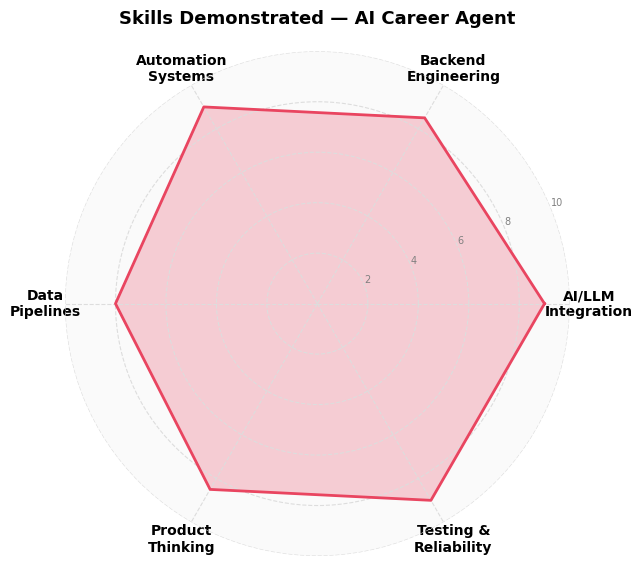

In [7]:
# Portfolio skills radar — what this project demonstrates
import matplotlib.pyplot as plt
import numpy as np

skills = [
    "AI/LLM\nIntegration",
    "Backend\nEngineering",
    "Automation\nSystems",
    "Data\nPipelines",
    "Product\nThinking",
    "Testing &\nReliability",
]
scores = [9, 8.5, 9, 8, 8.5, 9]

N = len(skills)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
scores_plot = scores + scores[:1]
angles     += angles[:1]

fig, ax = plt.subplots(figsize=(6.5, 6.5), subplot_kw=dict(polar=True))
ax.plot(angles, scores_plot, color="#e94560", linewidth=2)
ax.fill(angles, scores_plot, color="#e94560", alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(skills, fontsize=10, fontweight="bold")
ax.set_ylim(0, 10)
ax.set_yticks([2, 4, 6, 8, 10])
ax.set_yticklabels(["2", "4", "6", "8", "10"], fontsize=7, color="gray")
ax.grid(color="#dddddd", linestyle="--", linewidth=0.8)
ax.spines["polar"].set_visible(False)
ax.set_facecolor("#fafafa")
fig.patch.set_facecolor("white")

ax.set_title("Skills Demonstrated — AI Career Agent",
             fontsize=13, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig("assets/skills_radar.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 12. Final Summary

<div style="background: #f8f9fa; border-left: 4px solid #e94560; padding: 24px 28px; border-radius: 0 12px 12px 0; margin: 8px 0;">
  <h3 style="margin: 0 0 12px 0; color: #1a1a2e;">AI Career Agent is a career operations system.</h3>
  <p style="margin: 0; line-height: 1.8; color: #333;">
    It does not replace human judgment — it amplifies it. By automating the low-value parts of the
    job search workflow (discovery, deduplication, relevance scoring, status tracking), it frees the
    candidate to focus entirely on high-value decisions: <em>which roles are worth pursuing, and why.</em>
  </p>
</div>

### What was built

| Dimension | Detail |
|-----------|--------|
| **Sources** | 7 collector types — RSS, ATS (Greenhouse, Lever), HN, mock, Israeli boards |
| **Storage** | SQLite with 3 ORM models: Job, Score, StatusHistory |
| **Scoring** | 3 modes: keyword (V1), semantic themes (V2), embeddings (V3 optional) |
| **Automation** | APScheduler — collect every 6h, score 30m later; graceful fallback |
| **Dashboard** | Streamlit — 3 tabs, sidebar quick actions, status management |
| **LLM Layer** | Pluggable providers: Claude, OpenAI, Gemini, Ollama, Mock |
| **Tests** | 200 passing, 2 skipped (optional dependency), full CI via GitHub Actions |
| **Config** | YAML-driven: sources, profile, schedule — no code changes to customize |

### One-command startup

```bash
# Docker
docker compose up

# Local
python scripts/init_db.py
python scripts/fetch_jobs.py
python scripts/score_jobs.py
streamlit run dashboard/streamlit_app.py
```

---

<div style="text-align: center; padding: 20px; color: #888; font-size: 0.9em;">
  AI Career Agent · Built with Python, SQLAlchemy, Streamlit, and APScheduler<br>
  <em>Portfolio project · github.com/ORENS</em>
</div>